# RNA Preprocessing
_Disclaimer: This is a very extended example intended to show you the full functionality of Mother on RNA data, whilst also giving you fully functioning codes where you can easily swap out the example data with your own data. If you do end up using Mother for your projects, it would be greatly appreciated if you reference our packages and/or its contributors_

In this example, we demonstrate how to use custom preprocessing steps to include transcriptomics features in the model object. We show how to split the input features and define a custom preprocessing /feature selection routine for transcriptomic data and how to analyse the classifier downstream

There are two different ways to process RNA data, either classical normalisation with CPM (counts per million) or with single cell methodology through scanpy. 

I have included some additional functions and a data simulator so all functionalities of the classifier can be appropriately tests

### Setup
First we import some libabries and set up some functions we need later. Feel free to skip this section or read through the functions if you are really interested. They are extensively annotated

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import GroupKFold

import mother.ml as ml

Now we load the modules from the `rna` module. This is an optional package
with optional dependencies and has to be installed seperately via `pip install mother[rna]`. If you get
import errors here, that might be the issue.

In [2]:
from mother.ml.rna import RNA

Here I define some functions I will use later, feel free to skip.

In [3]:
import statsmodels.api as sm
from scipy.stats import nbinom
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from umap import UMAP


def simulate_rna_set(
    n_samples: int,
    n_genes: int = 1000,
    intended_classes: pd.Series = None,
    n_diverging_genes: int = 10,
    data_to_mirror: pd.DataFrame = None,
) -> pd.DataFrame:
    """
    Simulate an RNA dataset with specified characteristics.

    The function generates a synthetic RNA dataset, based on a starting RNA
    dataset if desired. It can accurately emulate different sequencing
    technologies or treatments. Using your actual training data as a start
    you can test whether the features selection works as expected. You can
    introduce a signal based on based on intended classes, and allows for
    the specification of diverging genes that are up- or down-regulated.
    Feature selection can thus be sanity checked by seeing whether it
    returns the diverging genes. Also this allows you to choose which
    normalisation works best for the data you have.

    If n_diverging genes is manually set to zero, there will be no
    diverging genes artificially set in the dataset. This is useful for
    using the rna simulator as a data augmentor.

    Parameters:
        n_samples (int): The number of samples in the dataset.
        n_genes (int): The number of genes in the dataset.
        intended_classes (pd.Series): The intended classes for each sample.
        n_diverging_genes (int): The number of genes that should be up- or
            down-regulated based on the intended classes.
        data_to_mirror (pd.DataFrame): Optional DataFrame to inform the simulation.

    Returns:
        pd.DataFrame: The simulated RNA dataset.
        pd.Series: The intended classes for each sample.
        list: The genes that are up- or down-regulated based on the intended classes.
    """

    # Initialize random number generator for reproducibility
    rng = np.random.default_rng(42)

    if data_to_mirror is not None:
        # Define a partial function for fitting the negative binomial distribution
        X = fit_negative_binomial(
            data_to_mirror,
            n_samples=n_samples,
            n_cols=n_genes,
        )
    else:
        # Default values if no data_to_mirror is provided
        mu = 2000
        n = 1 / 0.3
        p = n / (n + mu)
        X = pd.DataFrame(nbinom.rvs(n, p, size=(n_samples, n_genes)).astype(int))

    X.columns = [f"Gene_{i}" for i in range(X.shape[1])]

    if n_diverging_genes != 0:  # If artificial signal of up and down regulation is desired
        # Select diverging genes randomly from the baseline expression (not high not low clusters)
        diverging_genes = rng.choice(X.columns, size=n_diverging_genes, replace=False)
        new_gene_names = [f"Artificially_diverging_gene_{i + 1}" for i in range(n_diverging_genes)]
        diverging_dict = dict(zip(diverging_genes, new_gene_names))
        X.rename(columns=diverging_dict, inplace=True)

        # Generate intended classes if not provided
        if intended_classes is None:
            intended_classes = pd.Series(rng.choice(["A", "B", "C"], size=n_samples))

        # Add intended classes to the DataFrame
        X["intended_classes"] = intended_classes

        # Adjust the diverging genes based on the random factors
        for label in intended_classes.unique():
            random_factors = rng.choice([rng.uniform(0.001, 0.1), rng.uniform(10, 1000)], size=n_diverging_genes)
            X.loc[X["intended_classes"] == label, new_gene_names] *= random_factors

        # Clean up the DataFrame
        X.drop(columns=["intended_classes"], inplace=True)

    elif n_diverging_genes == 0 and n_genes == data_to_mirror.shape[1]:  # When no signal is to be introduced
        X.columns = data_to_mirror.columns
        new_gene_names = []

    # Clip values to a reasonable range and convert to int
    X = X.clip(lower=0, upper=1e6).astype(int)

    return X, intended_classes, new_gene_names


def stratified_grouped_train_test_split(X: pd.DataFrame, y: pd.Series, n_clusters: int) -> tuple:
    """
    Perform a stratified train-test split based on KMeans clustering.

    Parameters:
    - X (pd.DataFrame): Feature matrix.
    - y (pd.Series): Target labels.
    - n_clusters (int): Number of clusters for KMeans.

    Returns:
    - tuple: Split data (X_train, X_test, y_train, y_test).
    """
    # Step 1: Perform KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    groups = kmeans.fit_predict(X)

    # Step 2: Stratified Train-Test Split
    # We will use both the y labels and the cluster labels for stratification
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=[groups, y], random_state=42)
    return (X_train, X_test, y_train, y_test)


def fit_negative_binomial(data_to_mirror: pd.DataFrame, n_samples: int, n_cols: int) -> pd.DataFrame:
    """
    Fit a negative binomial distribution to the data and draw samples from it, incorporating modeled error.

    Parameters:
    - data_to_mirror (pd.DataFrame): The data to fit the negative binomial distribution to.
    - n_samples (int): The number of samples to draw.
    - n_cols (int): The number of columns in the output DataFrame.

    Returns:
    - pd.DataFrame: A DataFrame of size (n_samples, n_cols) with negative binomial samples drawn from a
        distribution with parameters estimated on the input data.
    """
    rng = np.random.default_rng(42)

    # Fit a Poisson model
    poisson_model = sm.GLM(np.ones(data_to_mirror.shape[1]), data_to_mirror.T, family=sm.families.Poisson()).fit()

    # Calculate the residuals
    # Ensure poisson_model.mu is reshaped to match data_to_mirror.T
    mu = poisson_model.mu
    residuals = data_to_mirror.mean().to_numpy() - mu

    # Estimate alpha
    alpha = np.var(residuals) / np.mean(mu)

    # Fit Negative Binomial model to the data
    model = sm.GLM(
        np.ones(data_to_mirror.shape[1]),
        data_to_mirror.T,
        family=sm.families.NegativeBinomial(alpha=alpha),
    )
    results = model.fit()

    # Calculate mean (mu) and dispersion (alpha)
    mu = data_to_mirror.mean(axis=0)
    alpha = results.scale

    # Calculate parameters for the negative binomial distribution
    n = 1 / alpha  # Number of successes until the experiment is stopped
    p = n / (n + mu)  # Probability of success in each trial
    expected_values = n * (1 - p) / p  # Calculate expected values

    # Calculate residuals as the difference between observed data and expected values
    residuals = data_to_mirror.T.apply(lambda x: x - expected_values)
    error = data_to_mirror.std().to_numpy()[:n_cols]

    # Subsample or oversample mu and error based on n_cols
    if n_cols < data_to_mirror.shape[1]:
        mu = np.array(sorted(mu))
        mu = mu[np.linspace(0, len(mu) - 1, n_cols).astype(int)]
        error = error[np.linspace(0, len(error) - 1, n_cols).astype(int)]
    elif n_cols > data_to_mirror.shape[1]:
        mu = rng.choice(mu, size=n_cols, replace=True)
        error = rng.choice(error, size=n_cols, replace=True)

    # Calculate parameters for the negative binomial distribution with adjusted mu
    n = 1 / alpha
    p = n / (n + mu)

    # Generate data from the negative binomial distribution
    negative_binomial_data = pd.DataFrame(nbinom.rvs(n, p, size=(n_samples, n_cols)).astype(int))

    # Generate noise based on the error and add it to the negative binomial data
    noise = rng.normal(loc=np.zeros(error.shape[0]), scale=error, size=negative_binomial_data.shape).astype(int)

    negative_binomial_data += noise

    # Ensure the values are non-negative
    negative_binomial_data = negative_binomial_data.clip(lower=0)

    return negative_binomial_data  # Return the noisy dataset


def distribution_compare(df1, df2, genes_to_highlight=None):
    """
    Compare the distribution of gene expression between two datasets.

    Parameters:
    - df1 (pd.DataFrame): First dataset.
    - df2 (pd.DataFrame): Second dataset.
    - genes_to_highlight (list): List of genes to highlight in the plot.

    Returns:
    - None
    """
    long_form_1 = pd.melt(df1.drop(columns=genes_to_highlight) + 1, value_name="Expression", var_name="Gene")
    long_form_2 = pd.melt(df1[genes_to_highlight] + 1, value_name="Expression", var_name="Gene")
    long_form_3 = pd.melt(df2 + 1, value_name="Expression", var_name="Gene")
    long_form_1["Dataset"] = "Simulated RNA data"
    long_form_2["Dataset"] = "Simulated differentially expressed genes"
    long_form_3["Dataset"] = "Real RNA data"

    sns.kdeplot(
        data=pd.concat([long_form_1, long_form_2, long_form_3]),
        x="Expression",
        hue="Dataset",
        log_scale=True,
        cut=0,
        common_norm=False,
    )
    ax = plt.gca()
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    plt.show()


def plot_embedding(data, labels=None, algorithm="umap"):
    """
    Plot the embedding of the data using UMAP or PCA.

    Parameters:
    - data (pd.DataFrame): Data to embed.
    - labels (pd.Series): Labels for coloring the plot.
    - algorithm (str): Embedding algorithm to use ("umap" or "pca").

    Returns:
    - None
    """
    # Initialize PCA
    if algorithm == "umap":
        embedder = UMAP(n_components=2, random_state=42)
    else:
        embedder = PCA(n_components=2)

    # Fit and transform the RNA data
    embedding = embedder.fit_transform(data)

    # Plotting
    if not isinstance(labels, list):
        labels = [labels]

    for label in labels:
        # Plot the PCA results
        sns.scatterplot(
            x=embedding[:, 0],
            y=embedding[:, 1],
            hue=label,
            palette="Set2",  # Optional: choose a color palette
        )
        ax = plt.gca()
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
        plt.show()


def add_pca(df: pd.DataFrame(), n_components: int = 10):
    # Clamp n_components to the number of available features/samples
    n_components = min(n_components, df.shape[0], df.shape[1])
    # Perform PCA on the bulk data
    embedder = PCA(n_components=n_components)
    embedding = embedder.fit_transform(df)
    embedding_df = pd.DataFrame(embedding, columns=[f"PC_{i + 1}" for i in range(embedding.shape[1])])
    embedding_df.index = df.index
    return (pd.concat([df, embedding_df], axis=1), embedder)

Let us load some small trial dataset that I have prepared. These are treated with DMSO and therefore act as a baseline to chemical pertubation experiments. Think of this as "business as usual" to the cell.

There are two different transcriptomics technologies that these sample data have been created with bulk RNA (costly but many reads) and alithea (high-throuhput but less reads)

As you can see the datasets only have a few samples (6) but a lot of columns == genes, which is not ideal for machine learning



In [4]:
df_bulk = pd.read_csv("../bulk_rna.csv", index_col=0)
df_alithea = pd.read_csv("../alithea_rna.csv", index_col=0)
print(df_bulk.shape)
print(df_alithea.shape)

(6, 11750)
(6, 12194)


As we cannot do much with 6 Now we create a random RNA dataset to test our RNA processing pipeline. We use our knowledge about RNA data to help us simulate data that is similar to our initial data. 

RNA count data is roughly distributed with a negative binomial distribution. An individual column represents the number of reads mapped to a gene. So there are as many columns as genes the organism has and the values of the columns are integers. For every column of the initial data we fit a negative binomial distribution and model the error rates of the different technologies. From these distributions we can now draw as many samples as we want to (there is a lot more stats-heavy stuff happening there here like modeling errors. I recommend looking at the functions simulate_rna_set and fit_negative_binomial they are extensively documented)

That however, won't help us much, since this is just a baseline, without any signal we are interested in. Therefore we just randomly assign our simulated data classes A, B and C. Within these classes we can set a desired number of genes to be either up or downregulated. This will be our artificial signal we are treating as gound truth to be discovered by our machine learner.

As the dataset simulator returns the genes it artificially differentially regulated we can check whether our feature selection works and whether our machine learner picks up the right signals

For the bulk data we are now generating 1000 samples with 5000 genes each

In [5]:
import warnings

warnings.filterwarnings("ignore")
simulated_bulk_data, labels_bulk, diverging_genes_bulk = simulate_rna_set(
    n_samples=1000,  # Number of samples to generate
    n_genes=5000,  # Number of genes to generate
    intended_classes=None,  # Intended classes for the samples, if you already had some in mind
    n_diverging_genes=10,  # Number of genes that should be up- or down-regulated
    data_to_mirror=df_bulk,  # Data to mirror
)

Lets have a look at the simulated data

In [6]:
simulated_bulk_data

,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4,Gene_5,Gene_6,Gene_7,Gene_8,Gene_9,...,Gene_4990,Gene_4991,Gene_4992,Gene_4993,Gene_4994,Gene_4995,Gene_4996,Gene_4997,Gene_4998,Gene_4999
0,61,0,384,286,0,0,51,0,0,0,...,39577,11472,78397,16040,67007,178107,220869,131883,1842,117603
1,0,0,0,130,14,0,0,113,0,12,...,15440,166087,14443,46808,21629,8698,88843,319852,262240,376783
2,35,79,0,0,51,34,592,0,0,30,...,293175,59663,40460,57071,3000,7623,146725,47263,2756,251222
3,187,84,383,134,25,144,164,127,0,0,...,2251,264502,62225,33436,150702,57670,133523,280901,68969,113815
4,0,78,0,0,0,541,295,0,0,0,...,32272,15506,98156,7970,127558,269154,432643,283377,155322,48277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,221,0,0,56,48,0,470,0,392,0,...,8595,100472,39749,29455,83400,27129,3557,14652,315176,151762
996,0,0,0,271,23,0,529,0,0,0,...,66819,187722,102681,235237,71591,272591,182181,120721,30016,382
997,328,16,785,439,0,0,0,160,0,0,...,9088,6801,156940,20553,189276,164186,20658,358055,209651,327236
998,241,0,0,0,0,0,0,0,0,81,...,3643,175396,129532,53421,20631,30372,50590,298498,34282,26769


Now the same for the alithea data

In [7]:
simulated_alithea_data, labels_alithea, diverging_genes_alithea = simulate_rna_set(
    n_samples=1000,  # Number of samples to generate
    n_genes=5000,  # Number of genes to generate
    intended_classes=None,  # Intended classes for the samples, if you already had some in mind
    n_diverging_genes=10,  # Number of genes that should be up- or down-regulated
    data_to_mirror=df_alithea,  # Data to mirror
)

In [8]:
simulated_alithea_data

,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4,Gene_5,Gene_6,Gene_7,Gene_8,Gene_9,...,Gene_4990,Gene_4991,Gene_4992,Gene_4993,Gene_4994,Gene_4995,Gene_4996,Gene_4997,Gene_4998,Gene_4999
0,10,0,50,20,0,0,5,0,0,0,...,701,7960,2123,976,525,13398,6071,8266,17152,116370
1,0,0,0,9,3,0,0,11,0,1,...,5605,9900,24341,4454,320,1665,14032,6797,8831,95784
2,6,8,0,0,12,1,63,0,0,3,...,2526,12100,14710,4751,7632,1117,22360,17367,7357,174810
3,32,9,50,9,6,6,17,13,0,0,...,3842,2399,13201,11922,6425,10649,6295,2088,24396,89283
4,0,8,0,0,0,24,31,0,0,0,...,6669,1504,357,11547,2668,16053,1,2485,0,102547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,38,0,0,4,11,0,50,0,16,0,...,2097,10295,541,432,666,1500,8104,12422,1984,294855
996,0,0,0,19,5,0,56,0,0,0,...,854,14890,5223,13618,3782,3004,2142,33146,269,146847
997,57,1,103,31,0,0,0,16,0,0,...,11959,20320,5733,3021,4577,9138,2177,8675,40550,1275
998,42,0,0,0,0,0,0,0,0,10,...,6708,4006,1080,2903,4004,1354,16768,20601,85337,24004


Now lets check whether the values generated in our artifical dataset actually look similar to the original sample data. I have also highlighter the distribution of the differentially regulated genes. These are expressed at either higher or lower level than the baseline expression (the big peak)

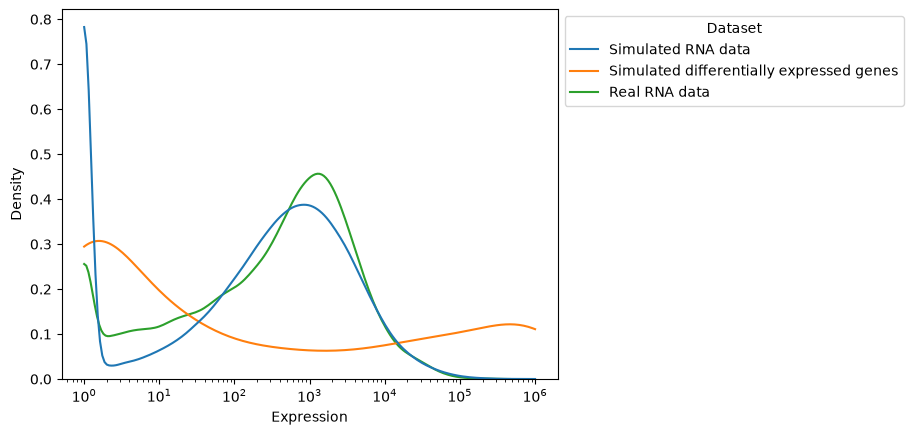

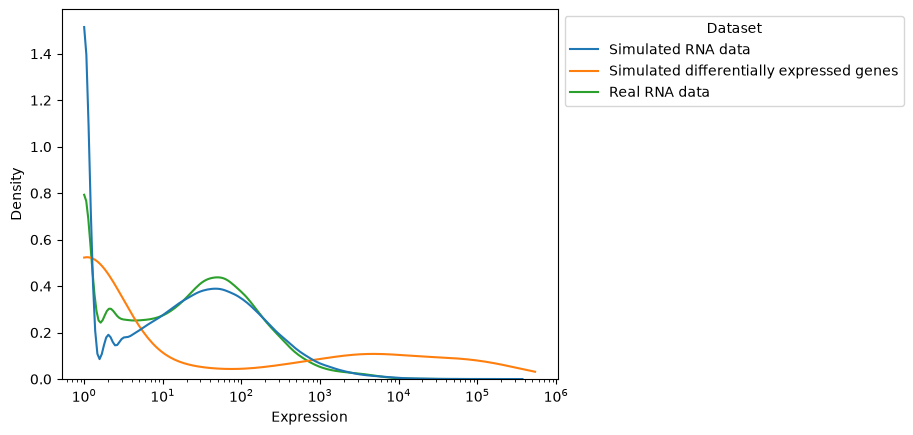

In [9]:
# KDEs are costly to plot, would downsample
distribution_compare(simulated_bulk_data.sample(100), df_bulk, diverging_genes_bulk)
distribution_compare(simulated_alithea_data.sample(100), df_alithea, diverging_genes_alithea)

This looks sufficiently similar let's check whether we find our artifically introduced classes in our RNA dataset (first by plotting a UMAP than by PCAs)

Bulk RNA UMAP


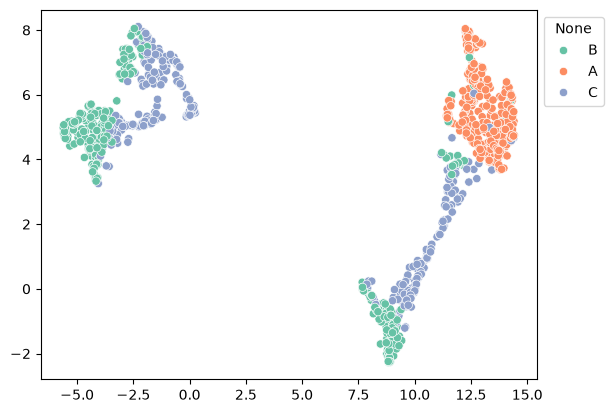

Bulk RNA PCA


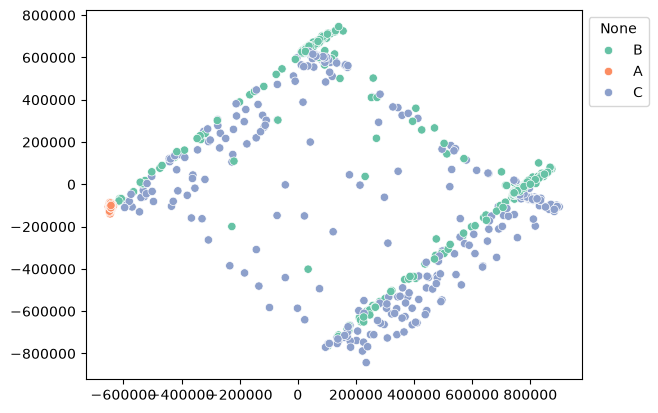

Alithea UMAP


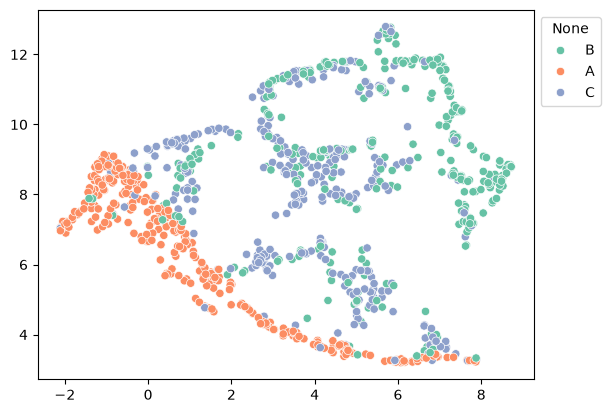

Alithea PCA


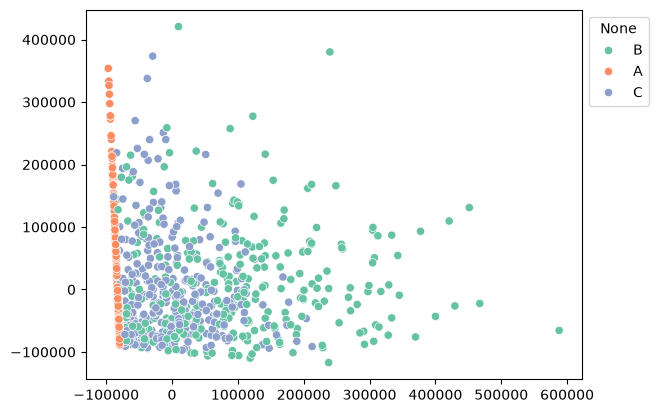

In [10]:
print("Bulk RNA UMAP")
plot_embedding(simulated_bulk_data, labels=labels_bulk, algorithm="umap")
print("Bulk RNA PCA")
plot_embedding(simulated_bulk_data, labels=labels_bulk, algorithm="pca")
print("Alithea UMAP")
plot_embedding(simulated_alithea_data, labels=labels_alithea, algorithm="umap")
print("Alithea PCA")
plot_embedding(simulated_alithea_data, labels=labels_alithea, algorithm="pca")

It looks like classes could actually be seperated by machine learning so lets dive right in

### RNA specific data processing

First let us split our data in training and testing so we can use the unseen test set to estimate the performance of our machine learner fitted on the training set

We use a clustered Train test split using kmeans clustering so similar samples either get sorted in training or testing to get a more accurate estimation of the machine learner ability to classify novel, unseen data

In [11]:
# Define the number of clusters for stratification
n_clusters = labels_bulk.nunique() * 4

# Split simulated bulk data
bulk_train_data, bulk_test_data, bulk_train_labels, bulk_test_labels = train_test_split(
    simulated_bulk_data, labels_bulk, test_size=0.3, stratify=labels_bulk, random_state=42
)

# Split simulated alithea data
alithea_train_data, alithea_test_data, alithea_train_labels, alithea_test_labels = train_test_split(
    simulated_alithea_data, labels_alithea, test_size=0.3, stratify=labels_alithea, random_state=42
)

# Free memory
simulated_bulk_data, simulated_alithea_data, labels_bulk, labels_alithea = None, None, None, None

Now we initialise our RNA pipeline.

Transcriptomics datasets usually contain as many columns=features as genes in the organism, so multiple 10s of thousands, all but a few are relevant for most prediction tasks. We therefore add a feature selection after the normalisation to select a more manageable amount. 

Depending on your data you can choose different normalisation strategies. The full
normalisation pipeline looks like this:

1. Preprocessing: Fill NAs with zero and remove zero variance columns.
2. Normalisation: The options are
- "Scanpy": Normalise with Scanpy which is appropriate for single-cell RNA and 
other sequencing technologies with 0 inflation (like Alithea).
- "UQ": Upper quartile normalisation
- "CUF": Counts adjusted with upper quartile normalisation
- "CPM": Counts per million normalisation
3. Feature selection: Lasso feature selection. You can set the n_features to None then it will select all features with non-zero regression coefficients.
4. Discretisation: Discretise the normalised distribution with geometric width discretiser.

This pipeline is fitted on the training data and then applied to the test data,  which avoids information leakage from training to testing.


Build the normalisation pipeline for bulk RNA data

In [12]:
RNA_pipe_bulk = RNA(
    n_features=None,  # Number of features (=genes)to keep for the prediction. If None this will keep all non-zero importance genes
    n_bins=20,  # Number of bins to use for the discretisation of the target variable.
    normalisation_method="CPM",  # Which normalisation to use
)._build_pipeline()

Lets print the bulk pipeline just to be sure

In [13]:
RNA_pipe_bulk

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalisation', ...), ('lasso_feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_features,None
,cv,5
,random_state,42
,variables,None
,bins,20
,return_object,False
,return_boundaries,False


Now lets fit it on our training data and transfrom both the training and testing

In [14]:
RNA_pipe_bulk.fit(bulk_train_data, bulk_train_labels)
normalised_bulk_train_data: pd.DataFrame = RNA_pipe_bulk.transform(bulk_train_data)
normalised_bulk_test_data: pd.DataFrame = RNA_pipe_bulk.transform(bulk_test_data)

Now we do the exact same for the alithea data

In [15]:
RNA_pipe_alithea = RNA(
    n_features=None,  # Number of features (=genes)to keep for the prediction. If None this will keep all non-zero importance genes
    n_bins=20,  # Number of bins to use for the discretisation of the target variable.
    normalisation_method="Scanpy",  # Which normalisation to use
)._build_pipeline()

RNA_pipe_alithea.fit(alithea_train_data, bulk_train_labels)
normalised_alithea_train_data: pd.DataFrame = RNA_pipe_alithea.transform(alithea_train_data)
normalised_alithea_test_data: pd.DataFrame = RNA_pipe_alithea.transform(alithea_test_data)

In [16]:
RNA_pipe_alithea

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalisation', ...), ('lasso_feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,min_genes,200
,min_cells,3
,target_sum,10000.0
,max_fraction,0.2
,n_bins,10
,n_features,None
,cv,5


Now if everything worked correctly, the feature selection should have selected the genes we artificially up and down regulated in the simulation step

In [17]:
found_bulk = len(set(normalised_bulk_train_data.columns).intersection(set(diverging_genes_bulk)))
found_alithea = len(set(normalised_alithea_train_data.columns).intersection(set(diverging_genes_alithea)))

print(
    f"Found {found_bulk} of {len(diverging_genes_bulk)} artificially diverging genes in bulk RNA data whilst selecting {normalised_bulk_train_data.shape[1]} features"
)
print(
    f"Found {found_alithea} of {len(diverging_genes_alithea)} artificially diverging genes in alithea RNA data whilst selecting {normalised_alithea_train_data.shape[1]} features"
)

Found 10 of 10 artificially diverging genes in bulk RNA data whilst selecting 13 features
Found 9 of 10 artificially diverging genes in alithea RNA data whilst selecting 10 features


Now we could trust this normalisation as is, but there is still a lot to learn about our underlying data. 

We therefore use the scanpy package to check some features of our simulated RNA dataset out of interest. The scanpy package has many built in functionalities and we can learn a lot through

For this mean we can simply isolate the scanpy normalisation from the scRNA pipeline we have built

In [18]:
RNA_pipe_alithea[0]

,min_genes,200
,min_cells,3
,target_sum,10000.0
,max_fraction,0.2
,n_bins,10


First let's check what the normalisation did to our data. I am transforming my orginal data again with the isolated step and plotting the distribution of our data before and after normalisation

Alithea data before normalisation


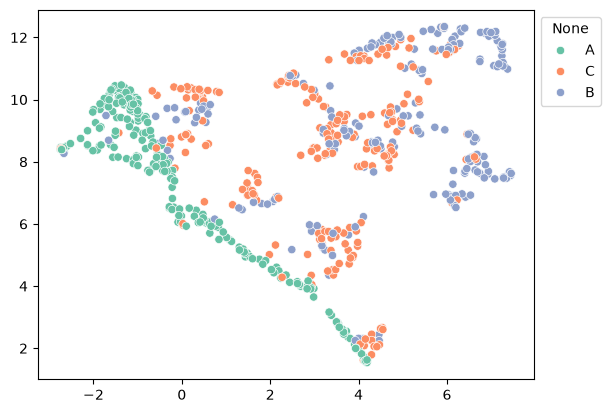

Alithea data after Normalisation


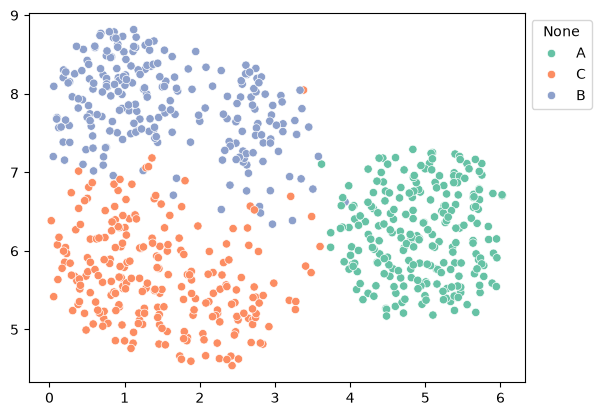

In [19]:
import anndata
import scanpy as sc

normalised_test = RNA_pipe_alithea[0].transform(alithea_train_data)
adata = anndata.AnnData(normalised_test)

print("Alithea data before normalisation")
plot_embedding(alithea_train_data, labels=alithea_train_labels, algorithm="umap")

print("Alithea data after Normalisation")
plot_embedding(adata.X, labels=alithea_train_labels, algorithm="umap")

Now we can use some of the built-in clustering algorithm from scanpy to let scanpy automatically define clusters from our data. We hope to see some of our artificial clusters A.B, and C in there. Further it might discover some sublusters. 

I am plotting both leiden clustering algorithm (which are unaware of any of the classes) next to our artifical clusters we know to be in the data

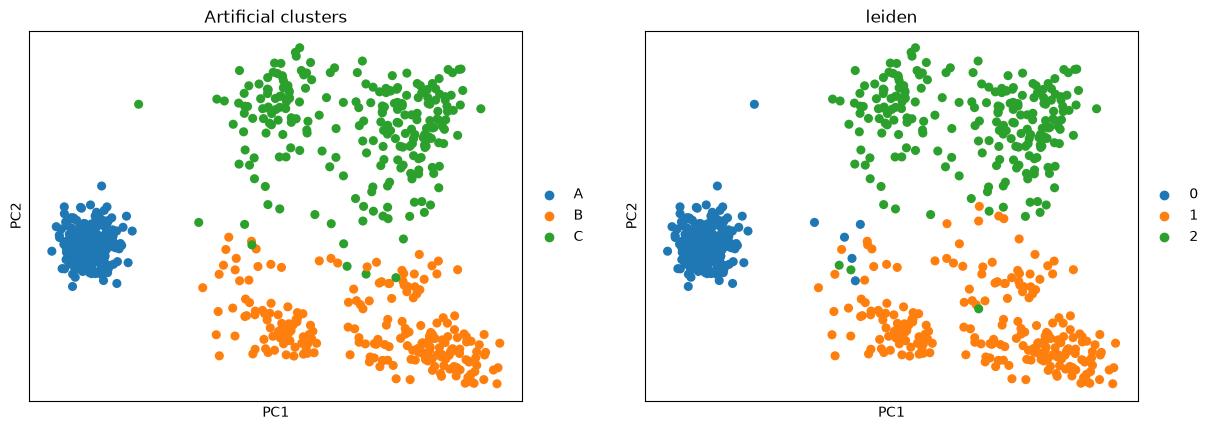

In [20]:
adata.obs["Artificial clusters"] = alithea_train_labels.to_numpy()
# Perform Principal Component Analysis (PCA)
sc.tl.pca(adata)

# Compute the neighborhood graph
sc.pp.neighbors(
    adata,
)

# Perform UMAP
sc.tl.umap(adata)

# Perform Leiden clustering
sc.tl.leiden(adata, resolution=0.5)


# Plot UMAP with the desired labels
sc.pl.pca(adata, color=["Artificial clusters", "leiden"])

Now we plot the 10 most important genes for every of the clusters we got from the leiden clustering, see if you can find our genes in there.

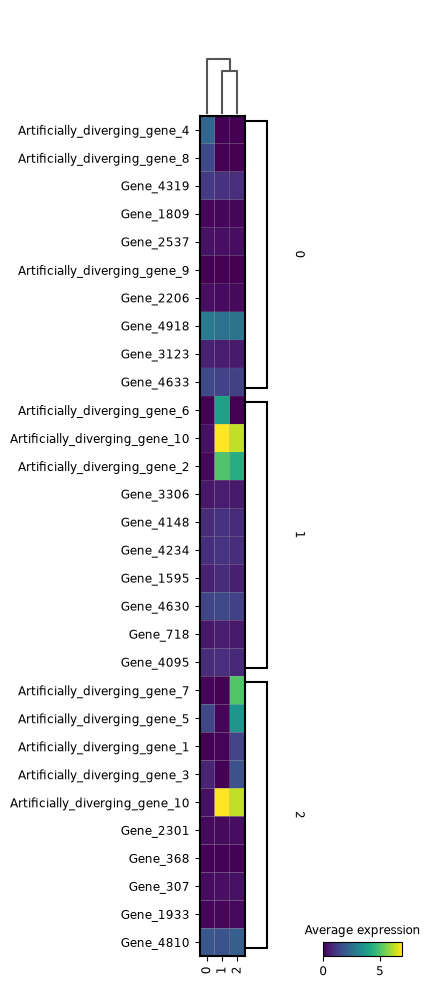

In [21]:
import scanpy as sc

sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups_matrixplot(
    adata,
    n_genes=10,
    swap_axes=True,  # Lay the plot on its side
    colorbar_title="Average expression",
)

We can also look at one of these clusters and compare the expression of the most important genes to the rest of the clusters. 

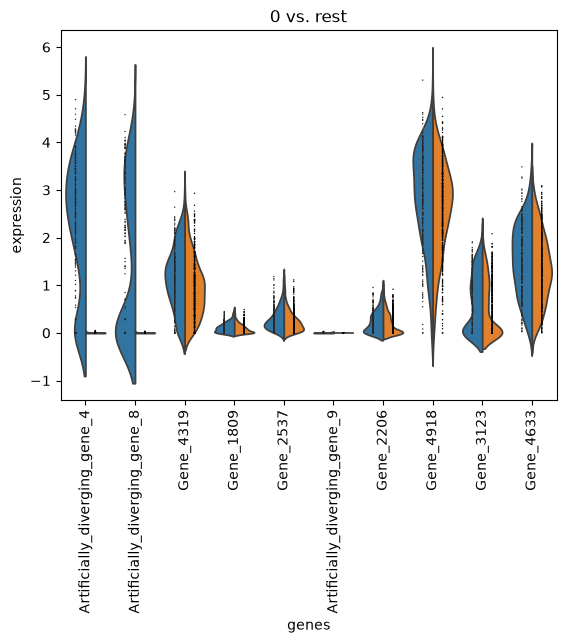

In [22]:
sc.pl.rank_genes_groups_violin(adata, n_genes=10, jitter=False, groups="0")

If you come from transcriptomic analysis you might be very familiar with volcano plots. We can also generate them from our clusters to check whether the genes we artificially up and down regulated actually are significantly differentially expressed above a log-fold-2 expression of -1 and +1 and above a p-value of 0.05

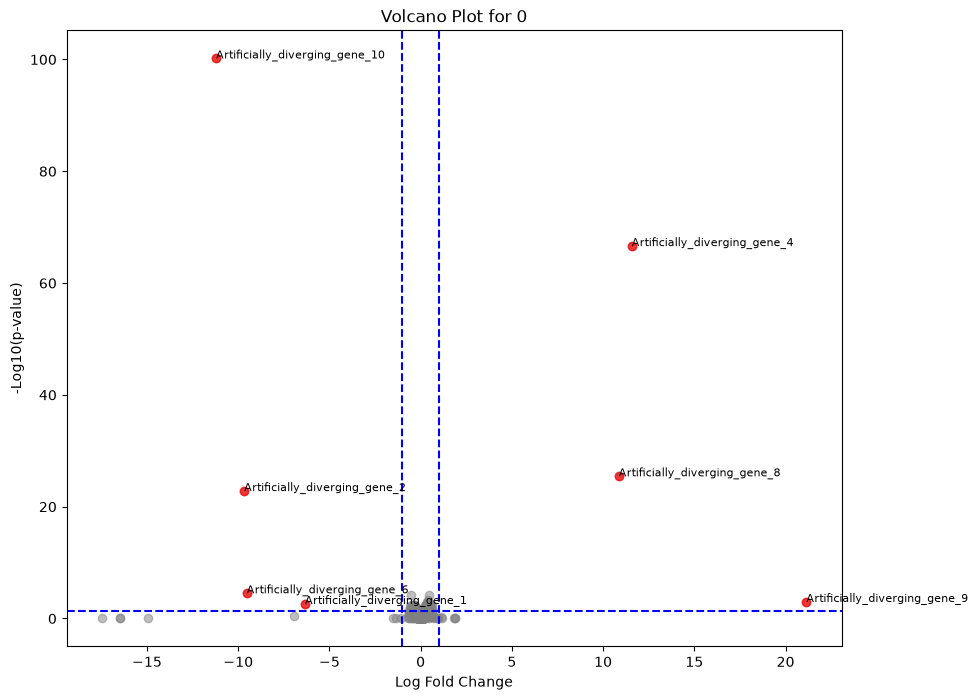

In [23]:
# Extract the results
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names
# Create a DataFrame with the results for one of the groups
group = groups[0]  # You can change this to the group you're interested in
df = pd.DataFrame(
    {"gene": result["names"][group], "logfoldchanges": result["logfoldchanges"][group], "pvals": result["pvals"][group]}
)

# Calculate -log10(p-value)
df["-log10(pvals)"] = -np.log10(df["pvals"])

# Create the volcano plot
plt.figure(figsize=(10, 8))
plt.scatter(df["logfoldchanges"], df["-log10(pvals)"], color="grey", alpha=0.5)

# Highlight significant genes (adjust thresholds as needed)
significant = df[(df["pvals"] < 0.05) & (np.abs(df["logfoldchanges"]) > 1)]
plt.scatter(significant["logfoldchanges"], significant["-log10(pvals)"], color="red", alpha=0.7)

# Add labels and title
plt.xlabel("Log Fold Change")
plt.ylabel("-Log10(p-value)")
plt.title(f"Volcano Plot for {group}")
plt.axhline(y=-np.log10(0.05), color="blue", linestyle="--")  # p-value threshold line
plt.axvline(x=-1, color="blue", linestyle="--")  # Log fold change threshold lines
plt.axvline(x=1, color="blue", linestyle="--")

# Optionally, annotate some significant genes
for i, row in significant.iterrows():
    plt.text(row["logfoldchanges"], row["-log10(pvals)"], row["gene"], fontsize=8)


plt.show()

Now that we are satisfied that all the signals we artificially introduced in our data is actually present in our data and the defining factor of variation, we can go try to leverage that signal to predict some of our classes

## RNA Machine learning

Disclaimer: As we are going deep into the machine learning now, I will start using a lot of jargon. Explaining all terminology would exceed the scope of this example. ChatGPT is very good at explaining these in detail

As we are only able to use a limited number of the multiple thousand genes before our machine learner takes too long we are selecting only a very select few genes. Now you might be worried we are missing some of the signal contained in the other thens of thousands and genes and you are correct. As a middle ground solution we are simply taking the first 10 principal components from the PCA and sticking them into the classifier to catch some of that residual signal in the data.

In [24]:
# Comment out if you dont want to add PCs
normalised_alithea_train_data, embedder = add_pca(normalised_alithea_train_data.copy(), n_components=10)
print(normalised_alithea_train_data.shape)
test_embedding = pd.DataFrame(
    embedder.transform(normalised_alithea_test_data),
    columns=[f"PC_{i + 1}" for i in range(embedder.n_components)],
)
test_embedding.index = normalised_alithea_test_data.index
normalised_alithea_test_data = pd.concat(
    [normalised_alithea_test_data, test_embedding],
    axis=1,
)

(700, 20)


Here you can now define which of the two datasets you would like to go forward with for machine learning. I have taken the alithea dataset here, but choose as you like

In [25]:
X_train = normalised_alithea_train_data.fillna(0)
X_test = normalised_alithea_test_data.fillna(0)
y_train = alithea_train_labels
y_test = alithea_test_labels
genes = diverging_genes_alithea

We now need to define some splits for our cross-validation. Again we use KMeans clustering to create a grouped k-fold cross-validation object, which we will use to tune our hyper-parameters from

In [26]:
# Perform K-means clustering
kmeans = KMeans(n_clusters=y_train.nunique() * 5, random_state=42)
groups: pd.DataFrame = kmeans.fit_predict(X_train)

cv = GroupKFold(n_splits=5)

Lets check whether the clusters for our fold actually represent our classes well

PCA first for labels then for groups


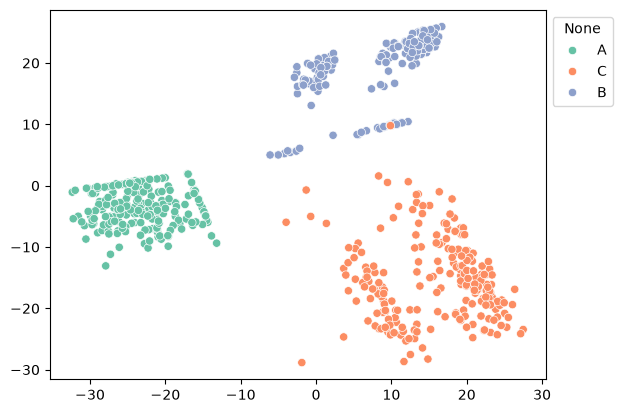

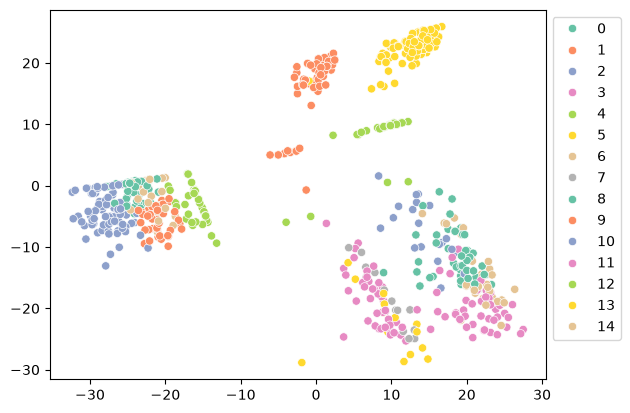

UMAP first for labels then for groups


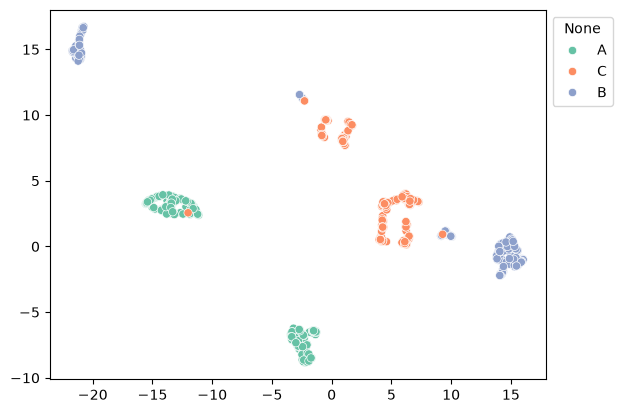

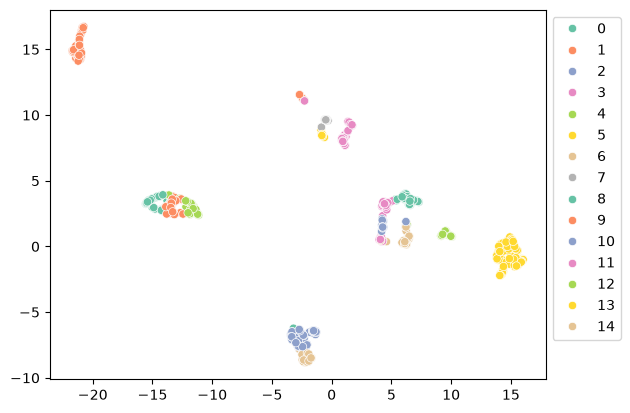

In [27]:
print("PCA first for labels then for groups")
plot_embedding(X_train, [y_train, groups], algorithm="pca")
print("UMAP first for labels then for groups")
plot_embedding(X_train, [y_train, groups], algorithm="umap")

Now lets train our machine learning model using the grouped k-fold cross validation we derived from the KMeans clustering

In [28]:
model = ml.PipelineWithHyperparameterRooting(
    [
        (
            "ml_model",
            ml.CatboostClassifierMother(
                target_type="single_target", model_type="classification_multiclass", logging_level="Silent"
            ),
        ),
    ]
)
# fit the model to data

model.fit(X_train, y_train)

,steps,"[('ml_model', ...)]"
,transform_input,None
,memory,None
,verbose,False


Now lets predict the test set and assess our machine learners performance

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix


def plot_accuracies(y_test, y_hat):
    # Generate confusion matrix
    conf_matrix = confusion_matrix(y_test, y_hat)

    # Display the confusion matrix
    ConfusionMatrixDisplay(confusion_matrix=conf_matrix).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    class_report = classification_report(y_test, y_hat, output_dict=True)
    print(classification_report(y_test, y_hat, output_dict=False))
    # Convert the classification report to a DataFrame
    class_report_df = pd.DataFrame(class_report).T

    # Plotting the heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        class_report_df.iloc[:-1, :].astype(float),
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        vmin=0,
        vmax=1,
    )
    plt.title("Classification Report Heatmap")
    plt.xlabel("Metrics")
    plt.ylabel("Classes")
    plt.show()

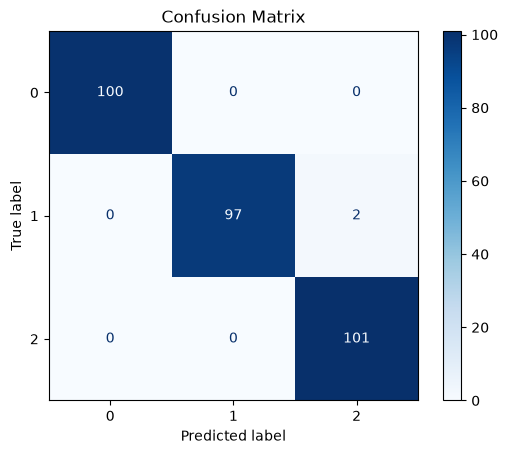

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       100
           B       1.00      0.98      0.99        99
           C       0.98      1.00      0.99       101

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



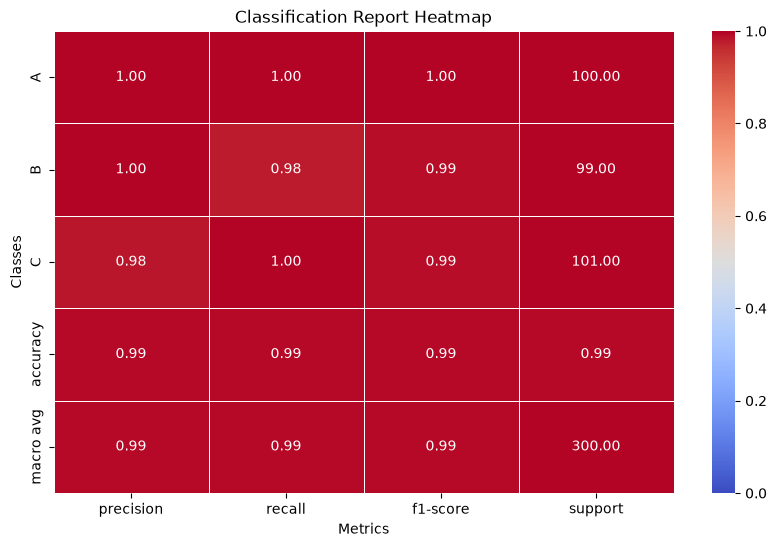

In [30]:
y_pred = model.predict(X_test)
plot_accuracies(y_test, y_pred)

Now that we know our machine learner performs well (this is very unsurprising given its artificial data with a very strong identifying signal), we can use some principles of explainable AI to see what the decision is based on. Here we are using Shapley-based explanations which borrow from game theory

In [31]:
import shap

# model[0].__class__.__name__ = "CatBoostClassifier"
explainer = shap.TreeExplainer(model[0], feature_names=X_train.columns)

We are now looking only at one class.
The following plots will tell you which features the model bases its decision on. Since we added principal components it will give you some hint on whether an individual gene is important up and above the linear combinations of multiple genes represented by the principal components

Class A vs Rest SHAP Values:


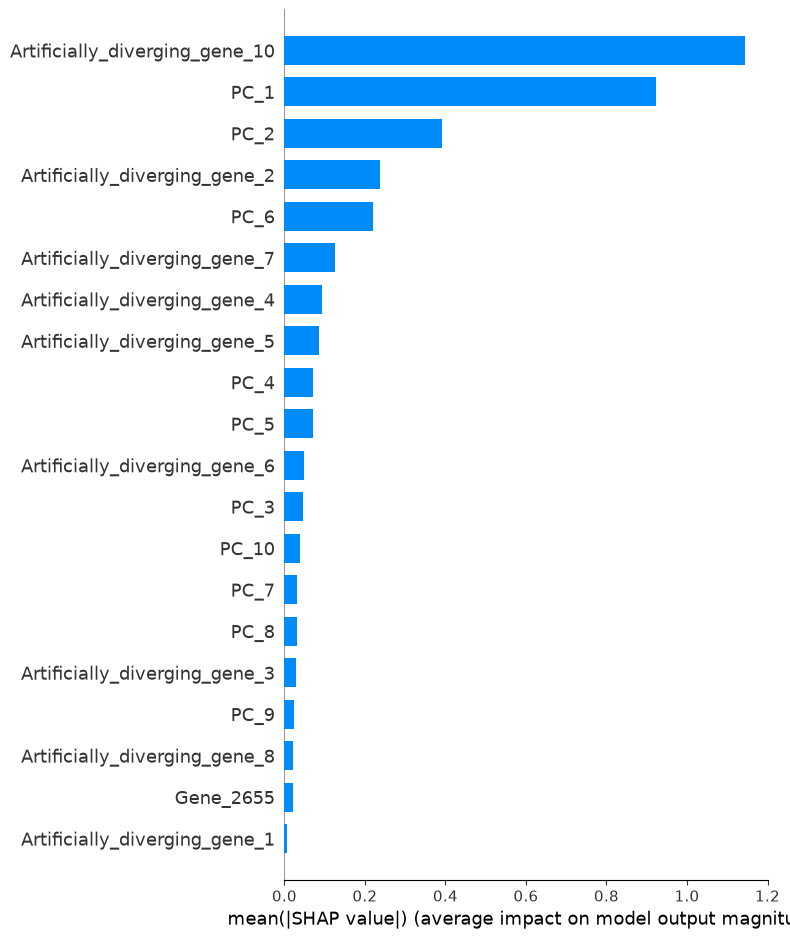

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Define feature names (replace with actual feature names if available)
feature_names = list(X_train.columns)

# Assuming model[0] is your trained model
explainer = shap.TreeExplainer(model[0], feature_names=feature_names)
shap_values = explainer.shap_values(X_train)
explanation = explainer(X_train)  # New style

class_index = 0
# Loop through each class

print(f"Class {y_train.unique()[class_index]} vs Rest SHAP Values:")

# Extract SHAP values for the current class
shap_values_for_class = shap_values[:, :, class_index]  # Shape will be (700, 30)

# Create a SHAP Explanation object for the current class
shap_explanation = shap.Explanation(
    values=shap_values_for_class,
    feature_names=feature_names,
    data=X_train,  # Include the original data if needed
    # base_values=explainer.expected_value[class_index]  # You can set this if you have base values
)

# Summary plot for the current class
shap.summary_plot(shap_values_for_class, X_train, feature_names=feature_names, plot_type="bar", show=True)

The following beeswarm plot will again tell you which features the machine learner bases is decision on, but it will also give you some insight whether a high or a low expression value leads to the samples being predicted as your class

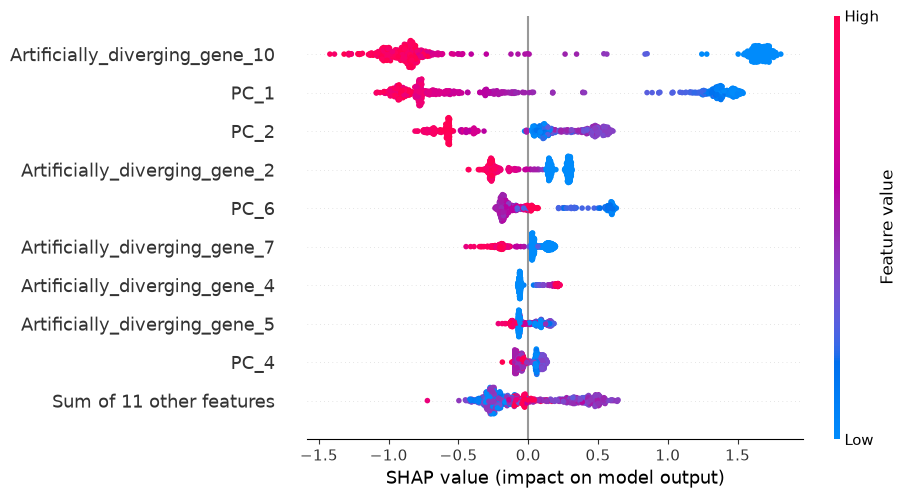

In [33]:
# Beeswarm plot for the current class
shap.plots.beeswarm(shap_explanation, max_display=10, show=True)

The next plot shows you all samples in your data and whether the value is high or low in the colour of the rows. The rows of features are ranked by importance. On top the trace shows you how the decision function changes dependent on the value of the plot. The samples predicted as this class are sorted to the right, on the left are samples belonging to other classes

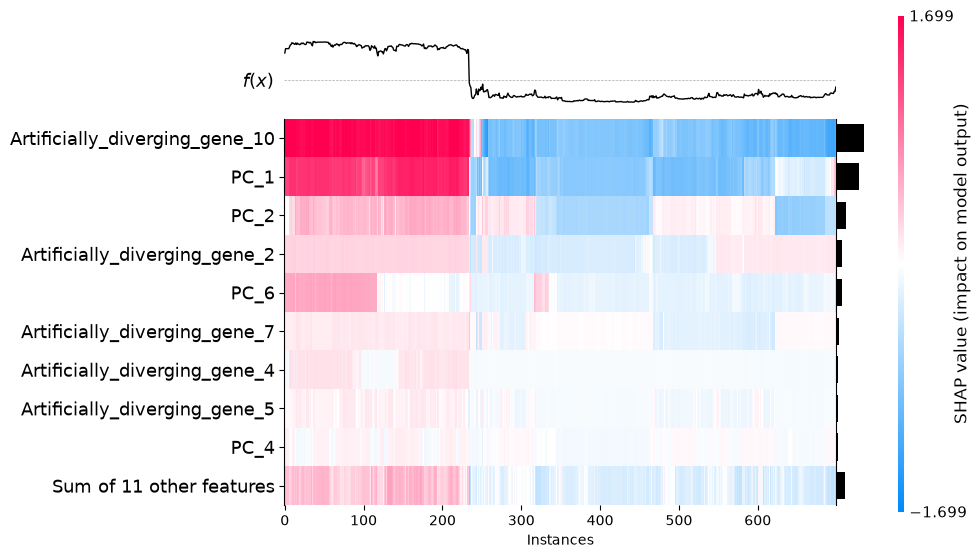

<Axes: xlabel='Instances'>

In [34]:
shap.plots.heatmap(explanation[:, :, 0])

This plots shows you the interaction of multiple features in contributing to your class prediction

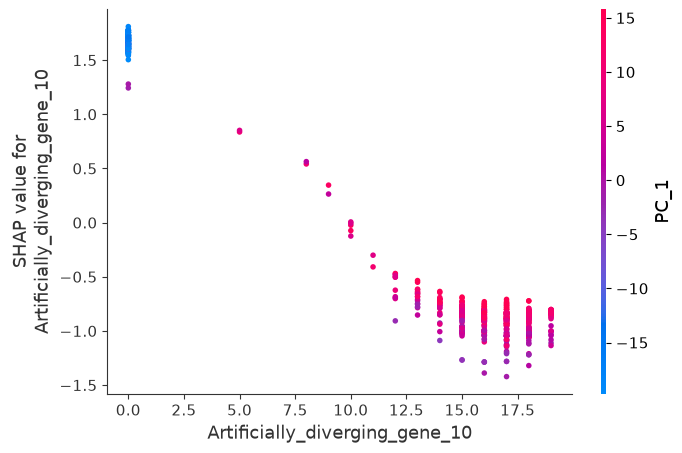

In [35]:
top_feature = np.argmax(np.abs(shap_values_for_class).mean(0))
shap.dependence_plot(top_feature, shap_values_for_class, X_train, feature_names=feature_names, show=True)

Now we want to explore this interaction of features further, as this is specficially interesting for transcriptomics as we might find pathways of genes that explain our class.

We are plotting a pairwise interaction matrix to get an overall signal

In [36]:
# Costly to compute
X_train_sample = X_train.sample(100)
shap_interaction = explainer.shap_interaction_values(X_train_sample)

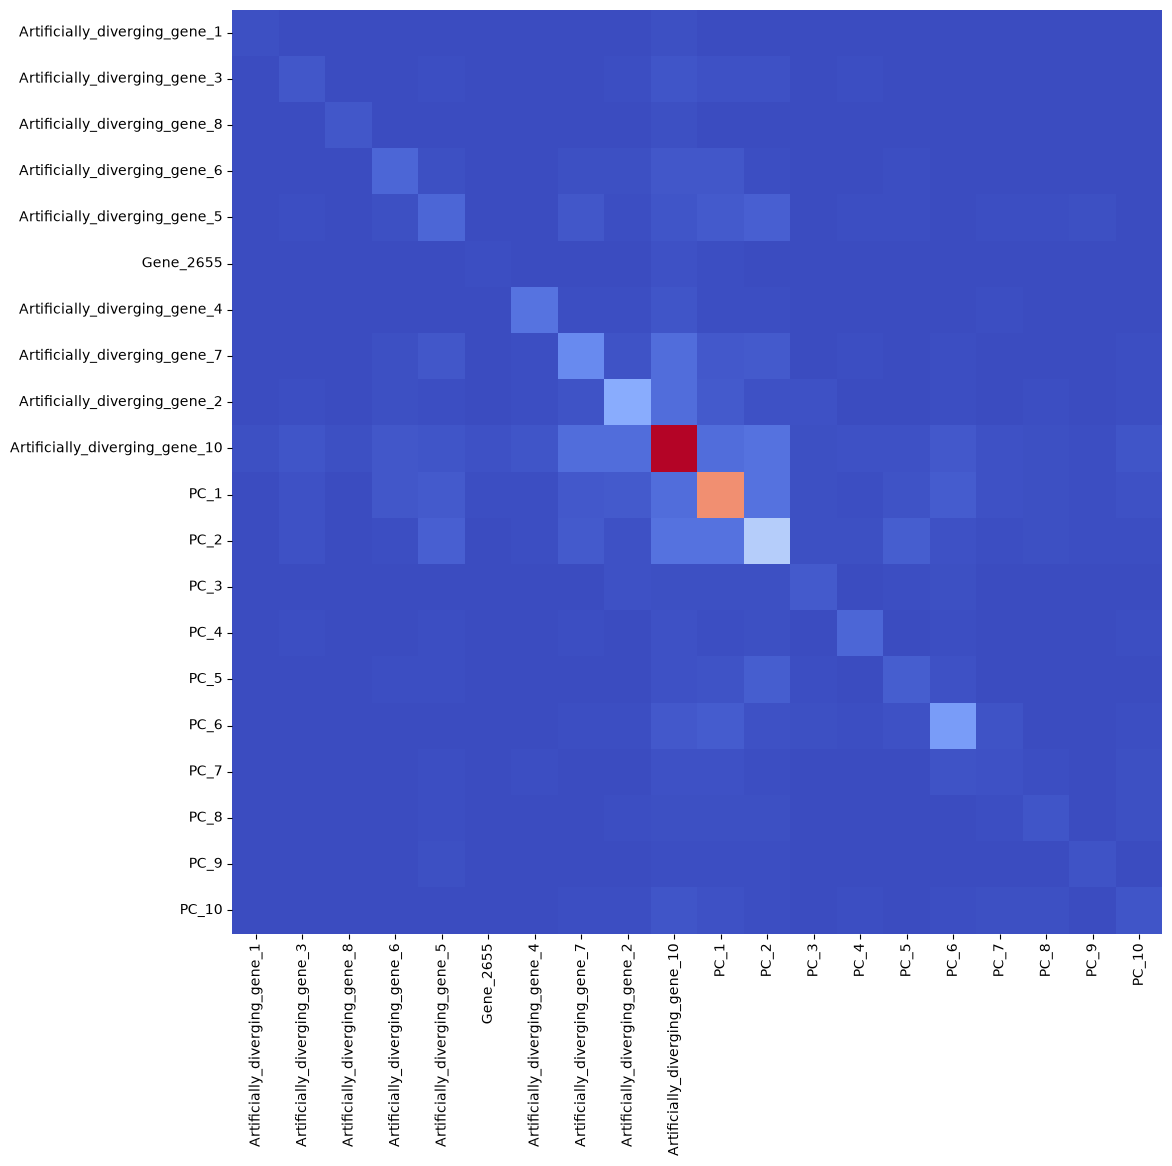

In [37]:
mean_shap = np.abs(shap_interaction[0]).mean(0)
df = pd.DataFrame(mean_shap, index=X_train.columns, columns=X_train.columns)

# times off diagonal by 2
df.where(df.to_numpy() == np.diagonal(df), df.to_numpy() * 2, inplace=True)

# display
fig = plt.figure(figsize=(12, 12), edgecolor="r")
ax = fig.add_subplot()
sns.heatmap(
    df.round(decimals=3),
    cmap="coolwarm",
    annot=False,
    fmt=".1f",
    cbar=False,
    ax=ax,
)

plt.yticks(rotation=0)
plt.show()

But we can also plot this for indiviual features

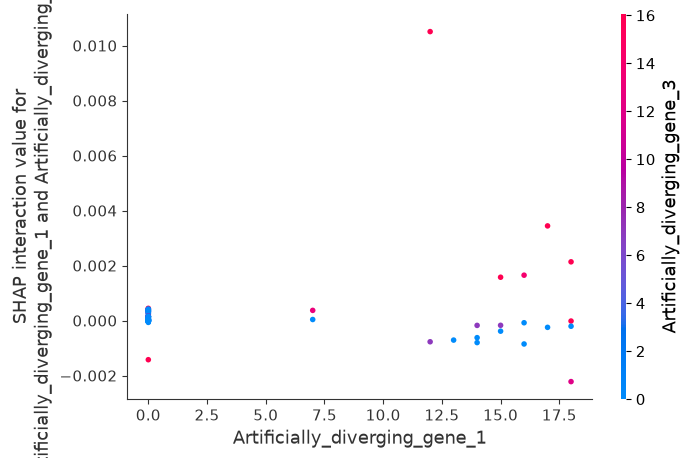

In [38]:
# plot feature interaction
shap.dependence_plot(list(X_train.columns)[:2], shap_interaction[0], X_train_sample, display_features=X_train_sample)

If this image is just a dot, there is not feature interaction between the features. You can adjust which feature interactions to check by using different slices of list(X_train.columns)[1:3]

Now these are some decision plots which show you how the inidivual genes contribute to the decision process. Every line here is one sample and the x-axis indicated the value of the corresponding feature of that sample 

In [39]:
import warnings

select = range(20)
features = list(X_train.columns)

expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]
print(f"Explainer expected value: {expected_value}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    shap_values = explainer.shap_values(X_train)
if isinstance(shap_interaction, list):
    shap_interaction = shap_interaction[1]

Explainer expected value: -0.14651851302725682


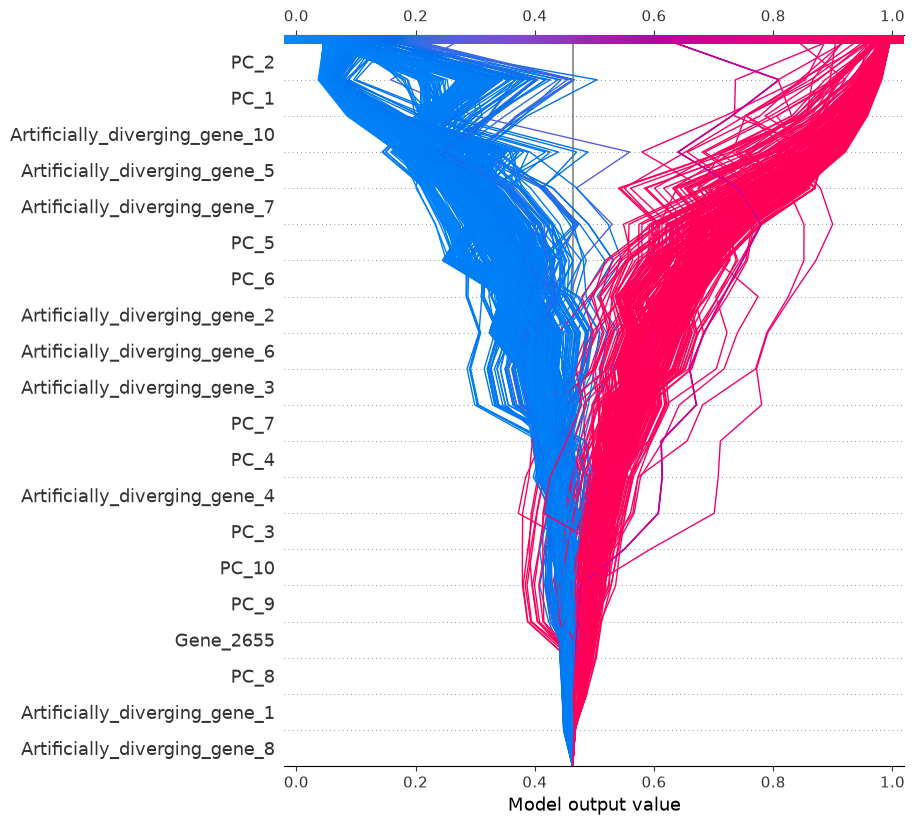

In [40]:
shap.decision_plot(expected_value, shap_values[:, :, -1], X_train, link="logit")

Now looking at an individual sample we can even see the individual feature values and how they contributed to the class prediction of this sample

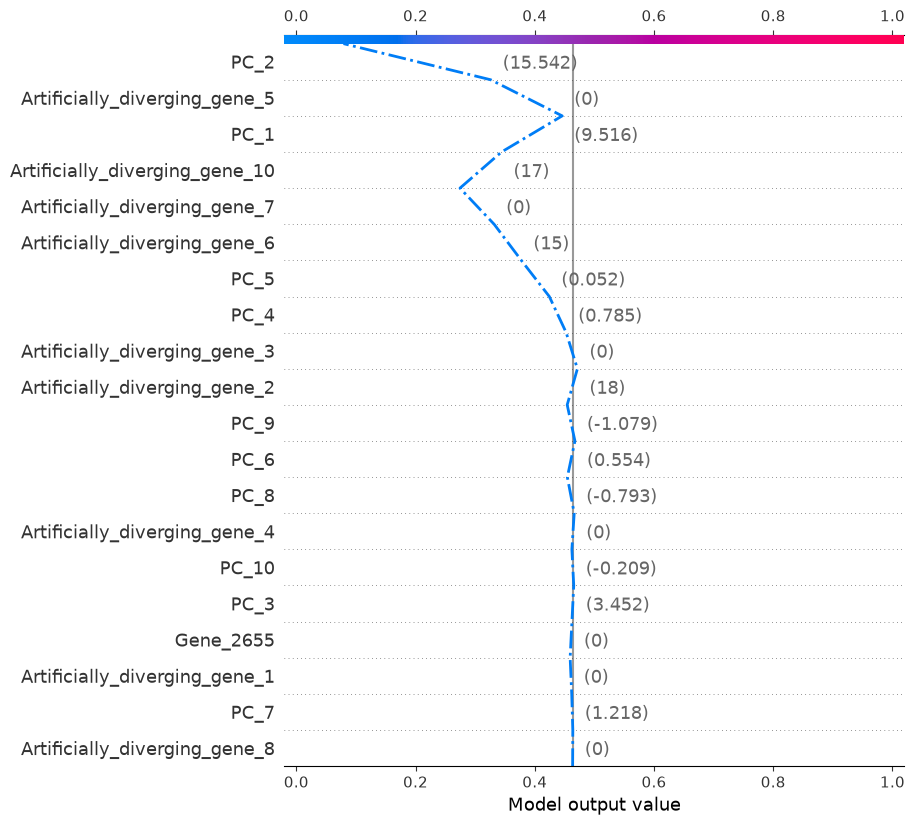

In [41]:
shap.decision_plot(expected_value, shap_values[2, :, -1], X_train.iloc[2], link="logit", highlight=0)

The following plots also summarise the contribution of each feature value into the class prediction of an individual sample

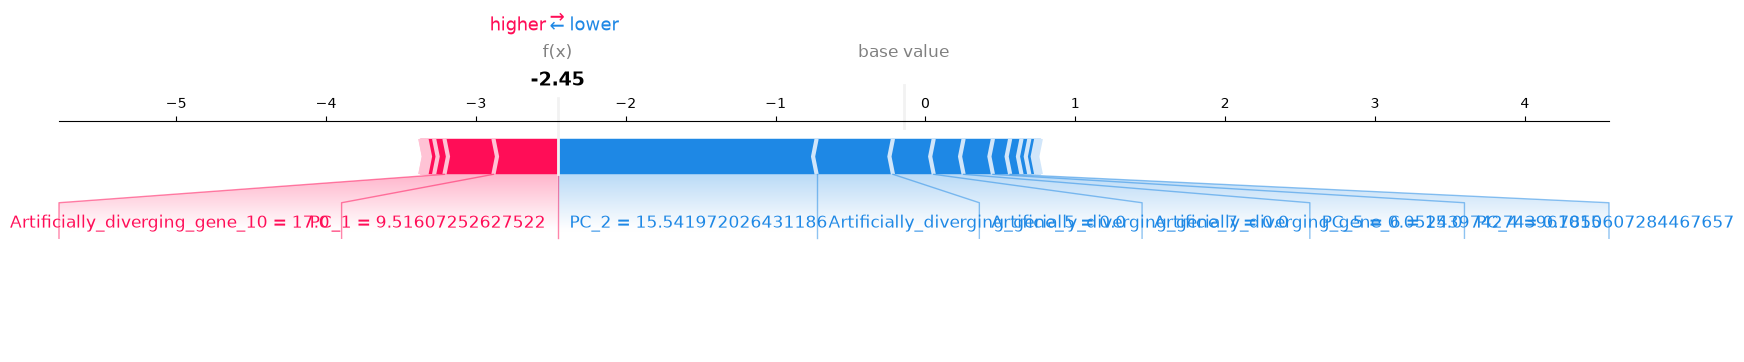

In [42]:
shap.force_plot(
    expected_value,
    shap_values[2, :, -1],
    X_train.iloc[2],
    matplotlib=True,
)

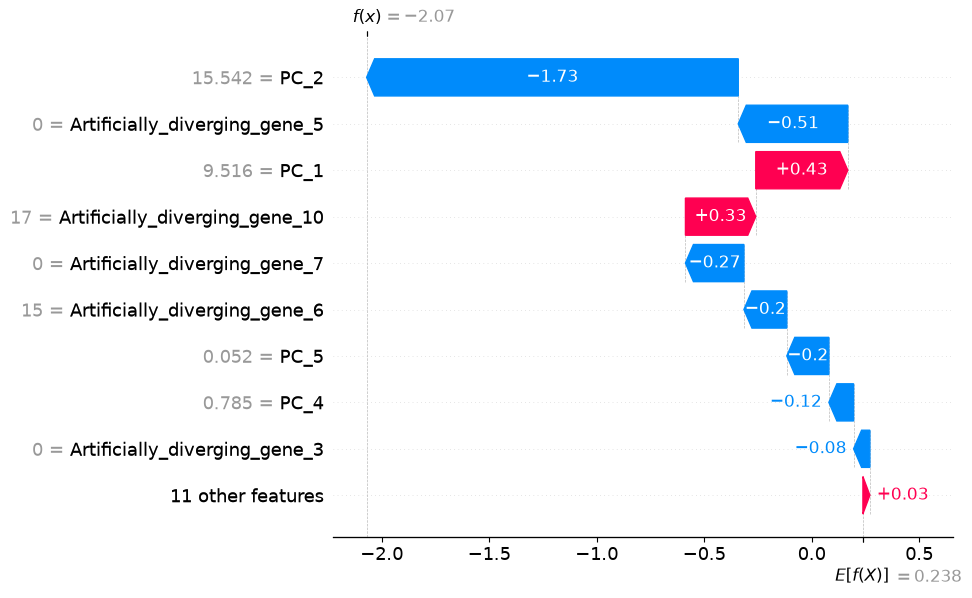

In [43]:
shap.plots.waterfall(explanation[2, :, -1])

# How to combine Chemical and transcriptomics data

Now we will turn to an example of mixing chemical information in the form of SMILES together with transcriptomic data. First we will make up some chamical data with some random classes.

In [44]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn import pipeline as sklearn_pipeline
from sklearn.model_selection import GroupKFold

import mother.ml as ml
from mother import feature_generation as fg
from mother.ml.rna import RNA
from mother.preprocessing import SmilesToMolTransformer

In [45]:
input_file: Path = Path("../freesolv_train.csv")
data: pd.DataFrame = pd.read_csv(input_file, sep=",")
data = data[["iupac", "smiles", "expt"]]
# add a string column to the data
data["target_col"] = np.random.choice([0, 1], data.shape[0])

Now we simulate some RNA data with the same classes

In [46]:
df_bulk = pd.read_csv("../bulk_rna.csv", index_col=0)

simulated_alithea_data, labels_alithea, diverging_genes_alithea = simulate_rna_set(
    n_samples=data.shape[0],  # Number of samples to generate
    n_genes=5000,  # Number of genes to generate
    intended_classes=data["target_col"],  # Intended classes for the samples, if you already had some in mind
    n_diverging_genes=10,  # Number of genes that should be up- or down-regulated
    data_to_mirror=df_bulk,  # Data to mirror
)

We will pre-process the chemical data in the form of SMILES strings to convert them to RDKit Mol objects

In [47]:
preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
    [
        ("smiles_to_mol", SmilesToMolTransformer()),
        # Add other column transformations here if needed
    ],
    memory=None,
).set_output(transform="pandas")

structure_data: pd.Series = data["smiles"].astype(str)
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)

Now lets generate some chemical features like Maccs- and Morgan fingerprints and some chemical descriptors

In [48]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[
        ("maccs", fg.MaccsFingerprints()),
        ("morgan", fg.MorganFingerprints()),
        ("desc", fg.ChemicalDescriptors()),
    ]
).set_output(transform="pandas")

features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"])
features = features.T.drop_duplicates().T

Lets now get some cross-validation object and split our data into training and testing

In [49]:
cv = GroupKFold(n_splits=5)

In [50]:
X = pd.concat((features, simulated_alithea_data), axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, data["target_col"], test_size=0.3, stratify=data["target_col"], random_state=42
)

X_test = X_test[X_train.columns]

In this custom model step we will combine the regular mother feature selection on the chemical data with the custom feature preprocessing (as in normalisation, MRMR etc.) for the transcriptomics

In [51]:
from mother.settings import MotherSettings
from mother import pipeline_utils as mother_takes_care

settings: MotherSettings = MotherSettings.create()
settings.model.feature_selection_flags = [
    "DROP_CONSTANT",
    "DROP_CORRELATED",
    "DROP_DUPLICATES",
    "DROP_UNIMPORTANT",
]

# Use the skl ColumnTransformer to combine the custom preprocessing with the usual feature selection
custom_model_step = ml.ColumnTransformerWithHyperparameterRooting(
    transformers=[
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(settings=settings, data=X_train, cv=cv),
            list(features.columns),  # Everything that goes into the regular feature selector
        ),
        (
            "rna_processing",
            RNA(
                n_features=15,  # Number of features (=genes)to keep for the prediction.
                n_bins=20,  # Number of bins to use for the discretisation of the target variable.
                normalisation_method="CPM",  # Whether to use single-cell RNAmethodology.
            )._build_pipeline(),
            list(simulated_alithea_data.columns),  # Everything that goes into RNA processing
        ),
    ]
).set_output(transform="pandas")

Here we fit and apply the model

In [52]:
model = ml.PipelineWithHyperparameterRooting(
    [
        ("custom_model_step", custom_model_step),
        (
            "ml_model",
            ml.CatboostClassifierMother(
                target_type="single_target", model_type="classification_binary", logging_level="Silent"
            ),
        ),
    ]
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

And now assess the accuracy on the test set

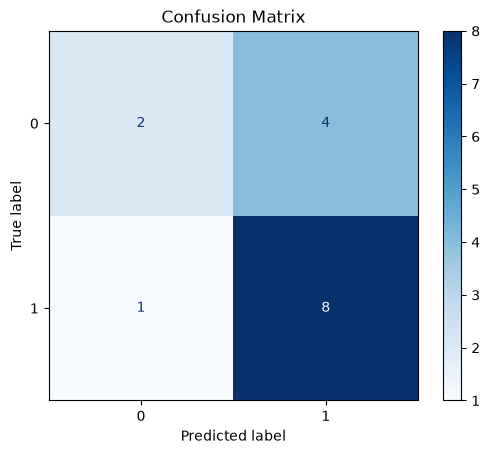

              precision    recall  f1-score   support

           0       0.67      0.33      0.44         6
           1       0.67      0.89      0.76         9

    accuracy                           0.67        15
   macro avg       0.67      0.61      0.60        15
weighted avg       0.67      0.67      0.63        15



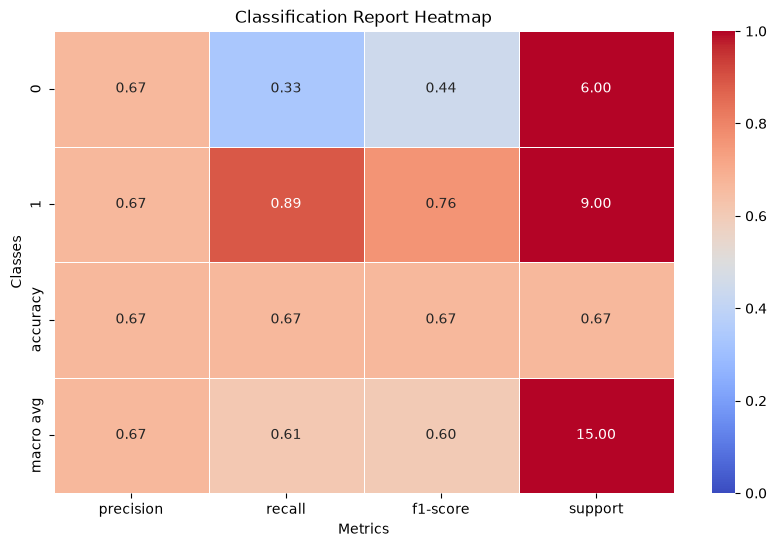

In [53]:
plot_accuracies(y_test, y_pred)

Let's also have a look at the explainability. Therefore we need the transformed data after the feature selection

In [54]:
X_train_feature_selected = model[0].transform(X_train)

Here you will now see mostly transcriptomics columns explaining the data, since there we artificially introduced a signal into the data. The chemical data unfortunately had random classes assigned to them and therefore cannot contribute meaningfully to any distinction in classification.

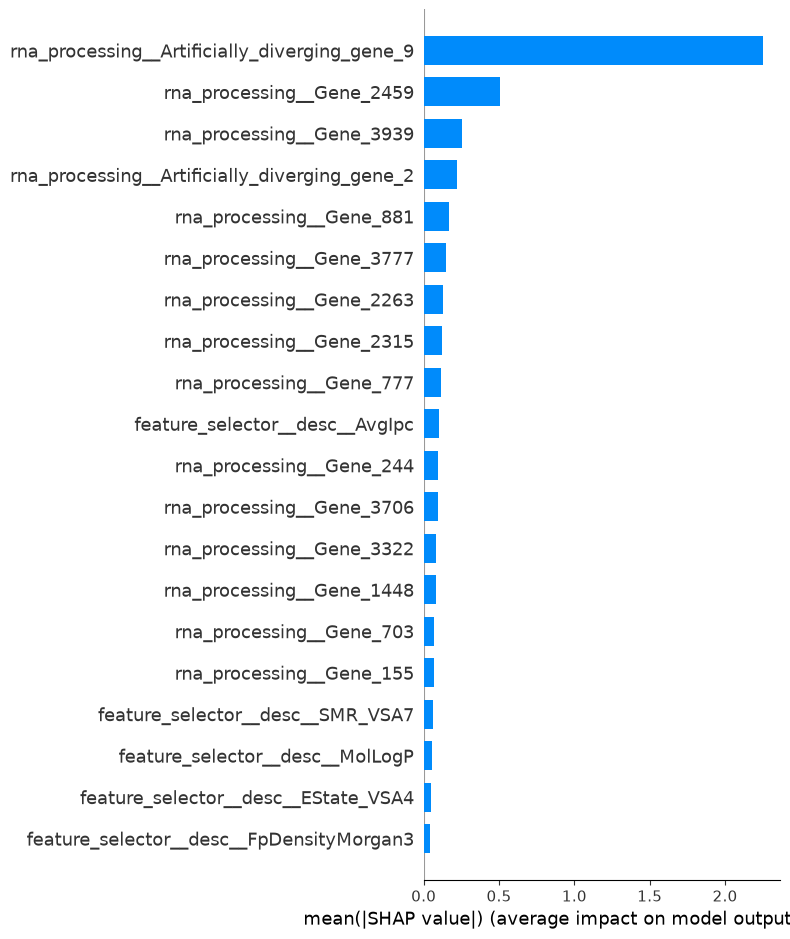

In [55]:
explainer = shap.TreeExplainer(model[1], feature_names=X_train_feature_selected.columns)

# Define feature names (replace with actual feature names if available)
feature_names = list(X_train_feature_selected.columns)

# Assuming model[0] is your trained model
explainer = shap.TreeExplainer(model[1], feature_names=feature_names)
shap_values = explainer.shap_values(X_train_feature_selected)
explanation = explainer(X_train_feature_selected)  # New style

# Create a SHAP Explanation object for the current class
shap_explanation = shap.Explanation(
    values=shap_values,
    feature_names=feature_names,
    data=X_train_feature_selected,  # Include the original data if needed
    # base_values=explainer.expected_value[class_index]  # You can set this if you have base values
)

# Summary plot for the current class
shap.summary_plot(shap_values, X_train_feature_selected, feature_names=feature_names, plot_type="bar", show=True)